In [10]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv(r"C:\Users\jitendra kumar\Downloads\telecom_customer_churn.csv")
df

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,Female,20,No,0,La Mesa,91941,32.759327,-116.997260,0,...,Credit Card,55.15,742.90,0.00,0,606.84,1349.74,Stayed,NaN,NaN
7039,9992-RRAMN,Male,40,Yes,0,Riverbank,95367,37.734971,-120.954271,1,...,Bank Withdrawal,85.10,1873.70,0.00,0,356.40,2230.10,Churned,Dissatisfaction,Product dissatisfaction
7040,9992-UJOEL,Male,22,No,0,Elk,95432,39.108252,-123.645121,0,...,Credit Card,50.30,92.75,0.00,0,37.24,129.99,Joined,NaN,NaN
7041,9993-LHIEB,Male,21,Yes,0,Solana Beach,92075,33.001813,-117.263628,5,...,Credit Card,67.85,4627.65,0.00,0,142.04,4769.69,Stayed,NaN,NaN


In [11]:
df.shape

(7043, 38)

In [12]:
df.columns.tolist()

['Customer ID',
 'Gender',
 'Age',
 'Married',
 'Number of Dependents',
 'City',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Number of Referrals',
 'Tenure in Months',
 'Offer',
 'Phone Service',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Customer Status',
 'Churn Category',
 'Churn Reason']

In [13]:
for col in df.columns:
    print(col)

Customer ID
Gender
Age
Married
Number of Dependents
City
Zip Code
Latitude
Longitude
Number of Referrals
Tenure in Months
Offer
Phone Service
Avg Monthly Long Distance Charges
Multiple Lines
Internet Service
Internet Type
Avg Monthly GB Download
Online Security
Online Backup
Device Protection Plan
Premium Tech Support
Streaming TV
Streaming Movies
Streaming Music
Unlimited Data
Contract
Paperless Billing
Payment Method
Monthly Charge
Total Charges
Total Refunds
Total Extra Data Charges
Total Long Distance Charges
Total Revenue
Customer Status
Churn Category
Churn Reason


In [14]:
df["Customer Status"].value_counts()

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

In [15]:
df["Customer Status"].value_counts(normalize = True)*100

Customer Status
Stayed     67.016896
Churned    26.536987
Joined      6.446117
Name: proportion, dtype: float64

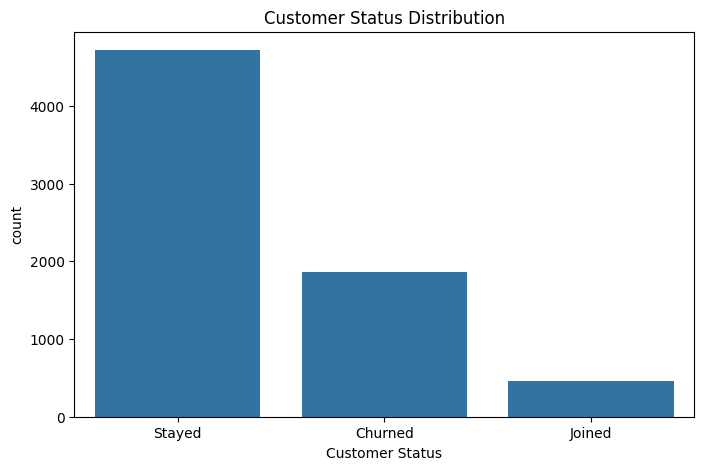

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Customer Status",
    data=df
)

plt.title("Customer Status Distribution")
plt.show()

In [17]:
df.isnull().sum().sort_values(ascending=False).head(20)

Churn Reason                         5174
Churn Category                       5174
Offer                                3877
Online Backup                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Streaming Movies                     1526
Streaming TV                         1526
Unlimited Data                       1526
Streaming Music                      1526
Internet Type                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Number of Dependents                    0
City                                    0
Age                                     0
Gender                                  0
Customer ID                             0
dtype: int64

In [18]:
df["Target"] = df["Customer Status"].apply(
    lambda x: 1 if x=="Churned" else 0
)

df["Target"].value_counts()

Target
0    5174
1    1869
Name: count, dtype: int64

In [19]:
pd.crosstab(
    df["Contract"],
    df["Target"],
    normalize = "index"
)*100

Target,0,1
Contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


In [20]:
#Churn by offer 

pd.crosstab(
    df["Offer"],
    df["Target"],
    normalize= "index"
)*100

Target,0,1
Offer,,
Offer A,93.269231,6.730769
Offer B,87.742718,12.257282
Offer C,77.108434,22.891566
Offer D,73.255814,26.744186
Offer E,47.080745,52.919255


In [21]:
#Customer churn by the Internet Type
pd.crosstab(
    df["Internet Type"],
    df["Target"],
    normalize="index"

)*100

Target,0,1
Internet Type,,
Cable,74.337349,25.662651
DSL,81.416465,18.583535
Fiber Optic,59.275124,40.724876


In [22]:
pd.crosstab(
    df["Gender"],
    df["Target"],
    normalize="index"
)*100

Target,0,1
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [23]:
pd.crosstab(
    df["Payment Method"],
    df["Target"],
    normalize="index"
    
)*100

Target,0,1
Payment Method,,
Bank Withdrawal,66.001535,33.998465
Credit Card,85.522008,14.477992
Mailed Check,63.116883,36.883117


In [24]:
pd.crosstab(
    df["Premium Tech Support"],
    df["Target"],
    normalize="index"
)*100

Target,0,1
Premium Tech Support,,
No,58.364526,41.635474
Yes,84.833659,15.166341


In [26]:
df_model= df.copy()
drop_cols = [
    "Customer ID",
    "City",
    "Zip Code",
    "Latitude",
    "Longitude",
    "Customer Status",
    "Churn Category",
    "Churn Reason"
]

df_model.drop(columns=drop_cols, inplace=True)

In [27]:
print(df_model.shape)

(7043, 31)


In [28]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   str    
 1   Age                                7043 non-null   int64  
 2   Married                            7043 non-null   str    
 3   Number of Dependents               7043 non-null   int64  
 4   Number of Referrals                7043 non-null   int64  
 5   Tenure in Months                   7043 non-null   int64  
 6   Offer                              3166 non-null   str    
 7   Phone Service                      7043 non-null   str    
 8   Avg Monthly Long Distance Charges  6361 non-null   float64
 9   Multiple Lines                     6361 non-null   str    
 10  Internet Service                   7043 non-null   str    
 11  Internet Type                      5517 non-null   str    
 12  Avg

In [29]:
missing = df_model.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Offer                                3877
Avg Monthly GB Download              1526
Internet Type                        1526
Online Backup                        1526
Online Security                      1526
Streaming TV                         1526
Streaming Movies                     1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming Music                      1526
Unlimited Data                       1526
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
dtype: int64

In [30]:
internet_cols = [
    "Internet Type",
    "Online Security",
    "Online Backup",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Device Protection Plan",
    "Premium Tech Support",
    "Unlimited Data"
]

for col in internet_cols:
    df_model[col] = df_model[col].fillna("No Internet Service")

In [31]:
# Phone-related columns

df_model["Multiple Lines"] = df_model["Multiple Lines"].fillna("No Phone Service")

# Numeric columns

df_model["Avg Monthly Long Distance Charges"] = (
    df_model["Avg Monthly Long Distance Charges"].fillna(0)
)

df_model["Avg Monthly GB Download"] = (
    df_model["Avg Monthly GB Download"].fillna(0)
)

# Offer column
df_model["Offer"] = df_model["Offer"].fillna("No Offer")

In [33]:
df_model.isnull().sum().sum()

np.int64(0)

In [34]:
cat_cols = df_model.select_dtypes(include="object").columns

print(cat_cols)
print("\nTotal categorical columns:", len(cat_cols))

Index(['Gender', 'Married', 'Offer', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method'],
      dtype='str')

Total categorical columns: 18


C:\Users\jitendra kumar\AppData\Local\Temp\ipykernel_4024\3776515462.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include="object").columns


In [35]:
df_encoded = pd.get_dummies(
    df_model,
    columns=cat_cols,
    drop_first=True
)

In [36]:
print("Before Encoding :", df_model.shape)
print("After Encoding:", df_encoded.shape)

Before Encoding : (7043, 31)
After Encoding: (7043, 48)


In [37]:
df_encoded.select_dtypes(include ="object").columns

Index([], dtype='str')

In [38]:
X = df_encoded.drop("Target", axis=1)
y = df_encoded["Target"]

print(X.shape)
print(y.shape)

(7043, 47)
(7043,)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 47)
X_test : (1409, 47)
y_train: (5634,)
y_test : (1409,)


In [ ]:
# Model training 
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


c:\Users\jitendra kumar\OneDrive\Desktop\Churn retention\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [47]:
y_pred = lr.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [ ]:
#Model evaluation for accuracy 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8218594748048261
Precision: 0.6722689075630253
Recall   : 0.6417112299465241
F1 Score : 0.6566347469220246


In [49]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[918 117]
 [134 240]]


In [50]:
#classification report 
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1035
           1       0.67      0.64      0.66       374

    accuracy                           0.82      1409
   macro avg       0.77      0.76      0.77      1409
weighted avg       0.82      0.82      0.82      1409



In [51]:
#applying random forest on the datasets 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [52]:
# Evaluating random forest for accuracy 
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))



              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1035
           1       0.71      0.58      0.64       374

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [53]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.8246983676366217


In [ ]:
# confusion matrix 
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_pred))

[[946  89]
 [158 216]]


In [55]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,Tenure in Months,0.102899
2,Number of Referrals,0.097049
11,Total Revenue,0.082557
7,Total Charges,0.073209
43,Contract_Two Year,0.069408
6,Monthly Charge,0.066299
10,Total Long Distance Charges,0.046739
0,Age,0.042618
24,Internet Type_Fiber Optic,0.041576
1,Number of Dependents,0.039996


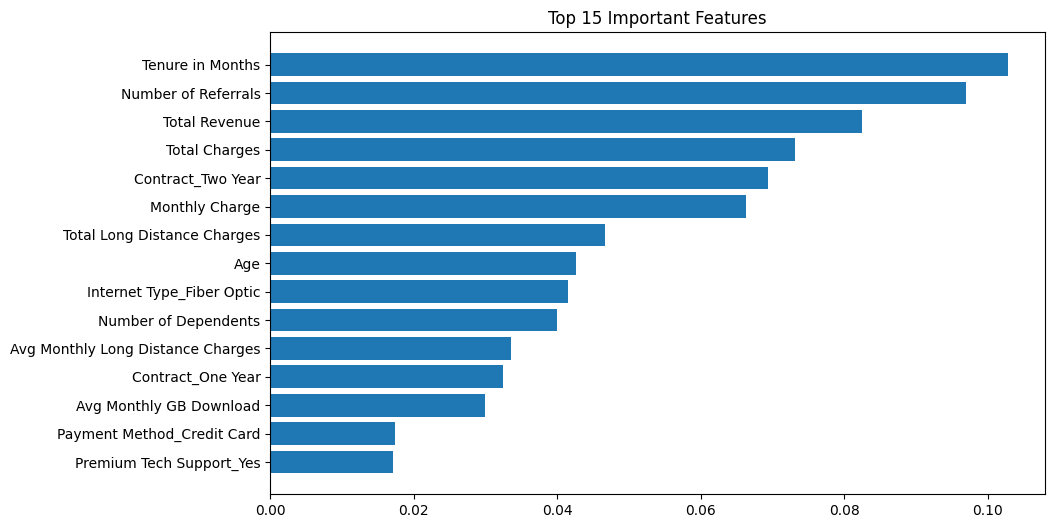

In [56]:
import matplotlib.pyplot as plt

top15 = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15["Feature"], top15["Importance"])
plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")
plt.show()

In [57]:
y_prob = rf.predict_proba(X_test)[:,1]

In [58]:
y_prob[:10]

array([0.15250057, 0.32679498, 0.24530759, 0.06857125, 0.07366339,
       0.01040942, 0.00847695, 0.03470535, 0.35338032, 0.70933265])

In [59]:
# Retention recommnendataion engine 
recommendations = []

for p in y_prob:

    if p > 0.80:
        recommendations.append("Offer 20% Discount")

    elif p > 0.60:
        recommendations.append("Provide Premium Tech Support")

    elif p > 0.40:
        recommendations.append("Offer Loyalty Reward")

    else:
        recommendations.append("No Action Needed")

In [60]:
results = X_test.copy()

results["Actual"] = y_test.values
results["Churn_Probability"] = y_prob
results["Recommendation"] = recommendations

results.head(10)

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,...,Unlimited Data_No Internet Service,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check,Actual,Churn_Probability,Recommendation
455,20,0,8,21,0.00,59.0,28.50,629.35,0.0,0,...,False,True,False,False,False,False,False,0,0.152501,No Action Needed
2301,75,0,0,11,2.63,13.0,111.40,1183.05,0.0,40,...,False,False,False,True,True,False,False,0,0.326795,No Action Needed
2255,77,0,0,4,30.11,25.0,69.35,261.65,0.0,0,...,False,True,False,True,False,False,False,0,0.245308,No Action Needed
4527,31,0,0,5,24.16,0.0,19.95,107.05,0.0,0,...,True,False,False,False,False,True,False,0,0.068571,No Action Needed
3812,32,1,1,72,0.00,16.0,65.65,4664.50,0.0,60,...,False,False,False,True,True,False,False,0,0.073663,No Action Needed
5784,25,0,4,71,6.23,58.0,81.85,5924.40,0.0,0,...,False,True,False,True,False,False,False,0,0.010409,No Action Needed
3635,32,0,0,67,15.32,0.0,19.95,1311.75,0.0,0,...,True,False,False,True,False,False,False,0,0.008477,No Action Needed
3013,46,0,8,70,0.00,26.0,49.85,3370.20,0.0,0,...,False,True,False,True,True,False,False,0,0.034705,No Action Needed
5962,19,0,0,26,49.87,48.0,86.65,2208.75,0.0,0,...,False,True,False,False,True,True,False,0,0.353380,No Action Needed
1628,43,0,0,5,38.89,8.0,104.10,541.90,0.0,0,...,False,True,False,False,False,False,True,1,0.709333,Provide Premium Tech Support


In [61]:
results.to_csv(
    "customer_retention_recommendations.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully


In [62]:
high_risk = results.sort_values(
    "Churn_Probability",
    ascending=False
)

high_risk[
    ["Churn_Probability", "Recommendation"]
].head(20)

,Churn_Probability,Recommendation
1804,0.903853,Offer 20% Discount
1719,0.898331,Offer 20% Discount
2634,0.891912,Offer 20% Discount
2292,0.889535,Offer 20% Discount
943,0.887794,Offer 20% Discount
5789,0.882690,Offer 20% Discount
1348,0.882014,Offer 20% Discount
5718,0.877464,Offer 20% Discount
2678,0.872668,Offer 20% Discount
1984,0.866600,Offer 20% Discount


In [63]:
results.to_csv(
    "customer_retention_recommendations.csv",
    index=False
)

In [64]:
import os 
os.listdir()

['.venv', 'Churn.ipynb', 'customer_retention_recommendations.csv']

In [65]:
final_df = df.loc[X_test.index].copy()

final_df["Actual"] = y_test.values
final_df["Churn_Probability"] = y_prob
final_df["Prediction"] = rf_pred
final_df["Recommendation"] = recommendations

final_df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Target,Actual,Churn_Probability,Prediction,Recommendation
455,0668-OGMHD,Female,20,Yes,0,Santa Rosa,95405,38.439696,-122.668817,8,...,0.00,629.35,Stayed,NaN,NaN,0,0,0.152501,0,No Action Needed
2301,3292-PBZEJ,Male,75,No,0,Greenview,96037,41.528541,-122.955018,0,...,28.93,1251.98,Stayed,NaN,NaN,0,0,0.326795,0,No Action Needed
2255,3223-DWFIO,Male,77,No,0,Forks Of Salmon,96031,41.232128,-123.194748,0,...,120.44,382.09,Stayed,NaN,NaN,0,0,0.245308,0,No Action Needed
4527,6377-KSLXC,Male,31,No,0,Fair Oaks,95628,38.652065,-121.254410,0,...,120.80,227.85,Stayed,NaN,NaN,0,0,0.068571,0,No Action Needed
3812,5360-XGYAZ,Male,32,Yes,1,Los Angeles,90040,33.994524,-118.149953,1,...,0.00,4724.50,Stayed,NaN,NaN,0,0,0.073663,0,No Action Needed


In [66]:
final_df.to_csv(
    "powerbi_customer_retention.csv",
    index=False
)

In [67]:
os.listdir()

['.venv',
 'Churn.ipynb',
 'customer_retention_recommendations.csv',
 'powerbi_customer_retention.csv']

In [68]:
print(os.getcwd())

c:\Users\jitendra kumar\OneDrive\Desktop\Churn retention


In [69]:
final_df.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason',
       'Target', 'Actual', 'Churn_Probability', 'Prediction',
       'Recommendation'],
      dtype='str')